In [1]:
import numpy as np
from functools import reduce

def daikei(a,b,h,f):
    N = int((b-a)/h)
    S = 0
    for i in range(N):
        xs = [a + i * h, a + (i+1) * h]
        S = S + h / 2 * (f(xs[0]) + f(xs[1]))
    return S

def simpson(a,b,h,f):
    N = int((b-a)/h)
    S = 0
    for i in range(1,N,2):
        xs = [a + (i-1) * h, a + i * h, a + (i+1) * h]
        S = S + h / 3 * (f(xs[0]) + 4 * f(xs[1]) + f(xs[2]))
    return S

In [ ]:
hs = [0.01/ (1 + x) for x in range(100)]
a = 0
b = 1

def f(x): return np.sqrt(1 - x ** 2)

daikei_y = np.asarray([daikei(a,b,hs[i],f) for i in range(len(hs))])
simpson_y = [simpson(a,b,hs[i],f) for i in range(len(hs))]

y = np.pi / 4

daikei_err = np.abs(y - daikei_y)
simpson_err = np.abs(y - simpson_y)

TypeError: unsupported operand type(s) for -: 'float' and 'list'

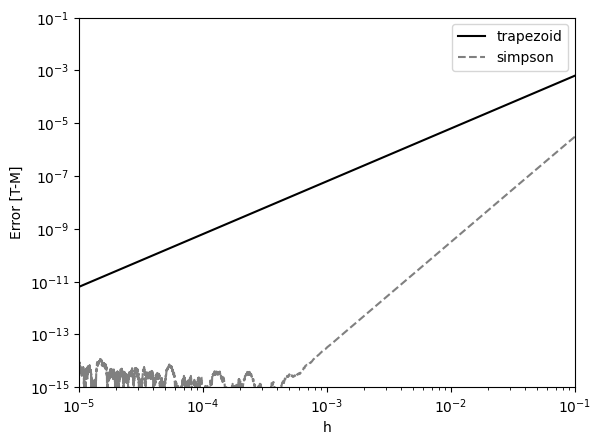

In [11]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.set_ylim(1e-15,0.1)
ax.set_xlim(1e-5,0.1)
ax.set_xscale('log',base=10)
ax.set_yscale('log',base=10)
ax.set_xlabel("h")
ax.set_ylabel("Error [T-M]")
ax.plot(hs,daikei_err,linestyle='solid',color='black')
ax.plot(hs,simpson_err,linestyle='--',color='grey')
ax.legend(['trapezoid','simpson'])

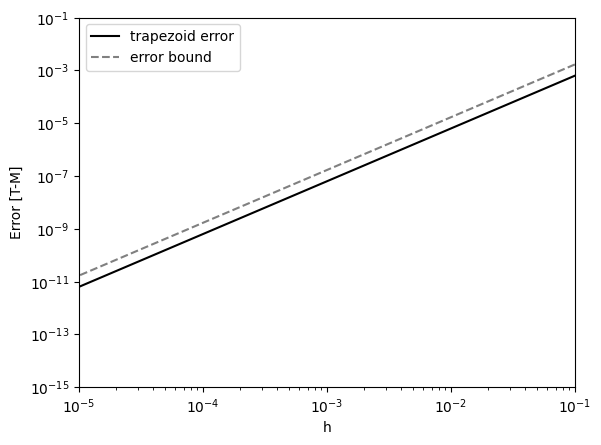

In [22]:
daikei_error_bounds = [1 * 1 / (6 * (n ** 2)) for n in ns]

fig, ax = plt.subplots()
ax.set_ylim(1e-15,0.1)
ax.set_xlim(1e-5,0.1)
ax.set_xscale('log',base=10)
ax.set_yscale('log',base=10)
ax.set_xlabel("h")
ax.set_ylabel("Error [T-M]")
ax.plot(hs,daikei_err,linestyle='solid',color='black')
ax.plot(hs,daikei_error_bounds,linestyle='--',color='grey')
ax.legend(['trapezoid error','error bound'])

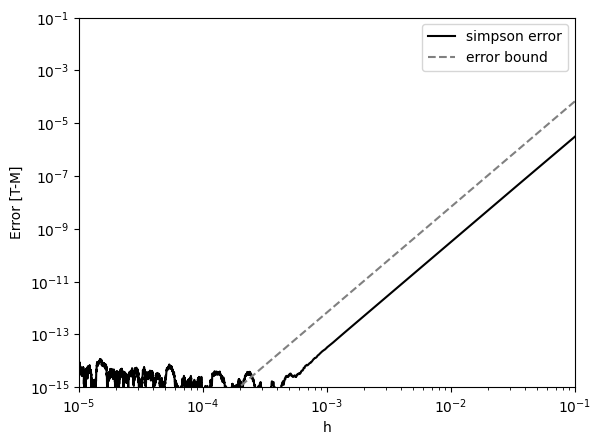

In [23]:
simpson_error_bounds = [2 * 1/ (3 * (n ** 4)) for n in ns]

fig, ax = plt.subplots()
ax.set_ylim(1e-15,0.1)
ax.set_xlim(1e-5,0.1)
ax.set_xscale('log',base=10)
ax.set_yscale('log',base=10)
ax.set_xlabel("h")
ax.set_ylabel("Error [T-M]")
ax.plot(hs,simpson_err,linestyle='solid',color='black')
ax.plot(hs,simpson_error_bounds,linestyle='--',color='grey')
ax.legend(['simpson error','error bound'])

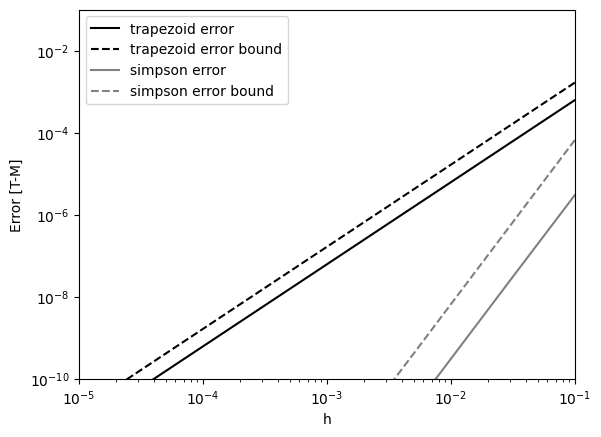

In [24]:
fig, ax = plt.subplots()
ax.set_ylim(1e-10,0.1)
ax.set_xlim(1e-5,0.1)
ax.set_xscale('log',base=10)
ax.set_yscale('log',base=10)
ax.set_xlabel("h")
ax.set_ylabel("Error [T-M]")
ax.plot(hs,daikei_err,linestyle='solid',color='black')
ax.plot(hs,daikei_error_bounds,linestyle='--',color='black')
ax.plot(hs,simpson_err,linestyle='solid',color='grey')
ax.plot(hs,simpson_error_bounds,linestyle='--',color='grey')
ax.legend(['trapezoid error','trapezoid error bound','simpson error','simpson error bound'])